# DETERMINISTIC PRETRAINING

In [1]:
import torch
import math
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd


In [2]:
print(torch.get_default_dtype())

torch.float32


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cpu


In [4]:
transform = transforms.ToTensor()

full_train = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

full_test = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# Keep only digits 0 and 1
train_indices = [i for i, (_, y) in enumerate(full_train) if y in [0, 1]]
test_indices = [i for i, (_, y) in enumerate(full_test) if y in [0, 1]]

train_dataset = Subset(full_train, train_indices)
test_dataset = Subset(full_test, test_indices)

batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))


Train size: 12665
Test size: 2115


In [5]:
#ORIGINAL INITIALIZATION IN THE PAPER
torch.nn.init.trunc_normal_

class DeterministicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 600)
        self.fc2 = nn.Linear(600, 600)
        self.fc3 = nn.Linear(600, 1)

        self._init_weights()

    def _init_weights(self):
        sigma = 0.04
        for m in [self.fc1, self.fc2, self.fc3]:
            nn.init.trunc_normal_(m.weight, mean=0.0, std=sigma, a=-2*sigma, b=2*sigma)
            nn.init.zeros_(m.bias)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return torch.sigmoid(x)


In [6]:
#The class given at first by GPT
class DeterministicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 600)
        self.fc2 = nn.Linear(600, 600)
        self.fc3 = nn.Linear(600, 1)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return torch.sigmoid(x)


In [7]:
model = DeterministicNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss() #Binary Cross-entropy Loss


In [8]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).float().unsqueeze(1)
            
            preds = model(x)
            predicted = (preds > 0.5).float()
            
            correct += (predicted == y).sum().item()
            total += y.size(0)
    
    return correct / total


In [9]:
epochs = 2

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device, dtype=x.dtype).unsqueeze(1)
        
        optimizer.zero_grad()
        preds = model(x)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    train_acc = evaluate(model, train_loader)
    test_acc = evaluate(model, test_loader)
    
    print(f"Epoch {epoch+1}")
    print(f"Loss: {total_loss/len(train_loader):.4f}")
    print(f"Train acc: {train_acc:.4f}")
    print(f"Test acc: {test_acc:.4f}")
    print("-"*30)


Epoch 1
Loss: 0.0500
Train acc: 0.9981
Test acc: 0.9986
------------------------------
Epoch 2
Loss: 0.0037
Train acc: 0.9994
Test acc: 0.9995
------------------------------


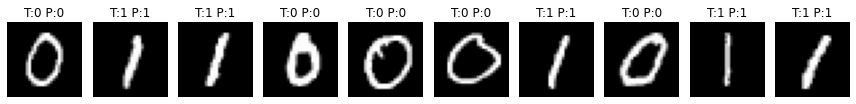

In [10]:
#Test to show that it works          
def show_images_with_predictions(model, dataset, num_images=10):
    model.eval()
    plt.figure(figsize=(12, 3))
   
    for i in range(num_images):
        idx = random.randint(0, len(dataset)-1)
        img, label = dataset[idx]
        
        x = img.unsqueeze(0).to(device)
        with torch.no_grad():
            prob = model(x).item()
            pred = int(prob > 0.5)
        
        plt.subplot(1, num_images, i+1)
        plt.imshow(img.squeeze(), cmap="gray")
        plt.title(f"T:{label} P:{pred}")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

show_images_with_predictions(model, train_dataset, num_images=10)


In [11]:
# Make sure `model` is your trained DeterministicNet
det_model = model.to(device)
det_model.eval()
# Save a copy of deterministic weights (so we can always go back)
det_state = {k: v.detach().clone() for k, v in det_model.state_dict().items()}

   # STOCHASTIC NEURAL NETWORK

In [12]:
class StochasticLinear(nn.Module):
    def __init__(self, in_features, out_features, prior_std=1.0, init_rho=-6.0):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.prior_std = float(prior_std)

        # Posterior parameters (learned)
        self.mu_weight = nn.Parameter(torch.empty(out_features, in_features))
        self.rho_weight = nn.Parameter(torch.empty(out_features, in_features))

        self.mu_bias = nn.Parameter(torch.empty(out_features))
        self.rho_bias = nn.Parameter(torch.empty(out_features))

        # Init (will be overwritten when we "load" from deterministic net)
        nn.init.normal_(self.mu_weight, mean=0.0, std=0.01)
        nn.init.constant_(self.rho_weight, init_rho)
        nn.init.zeros_(self.mu_bias)
        nn.init.constant_(self.rho_bias, init_rho)

    @staticmethod
    def softplus(x):
        return torch.log1p(torch.exp(x))  #Not used so far because original paper sigma = exp(rho)

    def sample_params(self):
        sigma_w = torch.exp(self.rho_weight)
        sigma_b = torch.exp(self.rho_bias)

        eps_w = torch.randn_like(sigma_w)
        eps_b = torch.randn_like(sigma_b)

        w = self.mu_weight + sigma_w * eps_w
        b = self.mu_bias + sigma_b * eps_b
        return w, b

    def forward(self, x):
        w, b = self.sample_params()
        return F.linear(x, w, b)

    def kl_divergence_to_isotropic_gaussian_prior(self):
        """
        KL( N(mu, diag(sigma^2)) || N(0, prior_std^2 I) )
        closed form, summed over all params in this layer.
        """
        prior_var = self.prior_std ** 2

        sigma_w = torch.exp(self.rho_weight)
        sigma_b = torch.exp(self.rho_bias)

        var_w = sigma_w ** 2
        var_b = sigma_b ** 2

        # 0.5 * sum( (var + mu^2)/prior_var - 1 - log(var/prior_var) )
        kl_w = ((var_w + self.mu_weight**2) / prior_var - 1.0 - torch.log(var_w / prior_var)).sum()
        kl_b = ((var_b + self.mu_bias**2) / prior_var - 1.0 - torch.log(var_b / prior_var)).sum()

        return 0.5 * (kl_w + kl_b)

    def load_from_deterministic(self, det_linear: nn.Linear):
        """Initialize posterior mean at deterministic weights, keep rho as-is."""
        with torch.no_grad():
            self.mu_weight.copy_(det_linear.weight.data)
            self.mu_bias.copy_(det_linear.bias.data)


In [13]:
class StochasticNet(nn.Module):
    def __init__(self, prior_std=1.0, init_rho=-6.0):
        super().__init__()
        self.fc1 = StochasticLinear(28*28, 600, prior_std=prior_std, init_rho=init_rho)
        self.fc2 = StochasticLinear(600, 600, prior_std=prior_std, init_rho=init_rho)
        self.fc3 = StochasticLinear(600, 1,   prior_std=prior_std, init_rho=init_rho)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return torch.sigmoid(x)

    def kl_divergence(self):
        return (
            self.fc1.kl_divergence_to_isotropic_gaussian_prior()
            + self.fc2.kl_divergence_to_isotropic_gaussian_prior()
            + self.fc3.kl_divergence_to_isotropic_gaussian_prior()
        )

    def load_from_deterministic_net(self, det_net: nn.Module):
        self.fc1.load_from_deterministic(det_net.fc1)
        self.fc2.load_from_deterministic(det_net.fc2)
        self.fc3.load_from_deterministic(det_net.fc3)


In [43]:
prior_std = 0.135 #approx e^(-2)
init_rho = -2. # small initial sigma via softplus(rho)

stoch_model = StochasticNet(prior_std=prior_std, init_rho=init_rho).to(device)
stoch_model.load_from_deterministic_net(model) #set the mean to deterministic net
stoch_model.eval()

print("Initialized stochastic posterior around the deterministic solution.")
print("Initial KL(Q||P):", float(stoch_model.kl_divergence().detach().cpu()))

def param_snapshot(model):
    with torch.no_grad():
        mu_norm = torch.norm(model.fc1.mu_weight).item()
        rho_mean = model.fc1.rho_weight.mean().item()
        sigma_mean = torch.exp(model.fc1.rho_weight).mean().item()
    return mu_norm, rho_mean, sigma_mean

print("Before:", param_snapshot(stoch_model))


Initialized stochastic posterior around the deterministic solution.
Initial KL(Q||P): 13281.1787109375
Before: (15.57275390625, -2.0, 0.13533534109592438)


In [15]:
def evaluate_stochastic(model, loader, mc_samples=5):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            # Average predictions over MC samples
            probs = 0.0
            for _ in range(mc_samples):
                probs = probs + model(x)
            probs = probs / mc_samples

            pred = (probs > 0.5).long().view(-1)
            correct += (pred == y).sum().item()
            total += y.numel()

    return correct / total

train_acc_stoch = evaluate_stochastic(stoch_model, train_loader, mc_samples=1)
test_acc_stoch  = evaluate_stochastic(stoch_model, test_loader,  mc_samples=1)

print("Stochastic Train acc (MC avg):", train_acc_stoch)
print("Stochastic Test  acc (MC avg):", test_acc_stoch)


Stochastic Train acc (MC avg): 0.816502171338334
Stochastic Test  acc (MC avg): 0.7976359338061466


# KL Inversion

In [16]:
## Bissection method to compute the little KL inverse q given q_hat and c

def binary_kl(p, q, eps=1e-12):
    p = torch.clamp(p, eps, 1 - eps)
    q = torch.clamp(q, eps, 1 - eps)
    return p * torch.log(p / q) + (1 - p) * torch.log((1 - p) / (1 - q))

@torch.no_grad()
def kl_inverse_upper(qhat, c, tol=1e-10, max_iter=80):
    """
    Returns the largest q in [qhat, 1) such that kl(qhat || q) <= c.
    Assumes q >= qhat.
    """
    qhat = torch.clamp(qhat, 0.0, 1.0)
    c = torch.clamp(c, 0.0)

    # Special-case qhat = 0 or 1 (closed forms, avoids numerical weirdness)
    if float(qhat) == 0.0:
        # kl(0||q) = -log(1-q) <= c  =>  q <= 1-exp(-c)
        return torch.clamp(1.0 - torch.exp(-c), 0.0, 1.0 - 1e-12)
    if float(qhat) == 1.0:
        # kl(1||q) = -log(q) <= c  =>  q >= exp(-c), but we want upper bound in [qhat,1)
        return torch.tensor(1.0 - 1e-12, device=qhat.device)

    lo = qhat.clone()
    hi = torch.ones_like(qhat) * (1.0 - 1e-12)

    # Invariant: feasible region is [qhat, lo], infeasible is [hi, 1)
    for _ in range(max_iter):
        mid = (lo + hi) / 2.0
        val = binary_kl(qhat, mid)

        if float(val) <= float(c):
            lo = mid  # mid is feasible; push up
        else:
            hi = mid  # mid infeasible; push down

        if float(hi - lo) < tol:
            break

    return lo


In [17]:
#Compute q_hat with Monte Carlo approx
@torch.no_grad()
def empirical_gibbs_risk_01(model, loader, mc_samples=10, device="cuda"):
    """
    Estimates \hat L(Q) = E_{w~Q}[ 1(f_w(x) != y) ] on the dataset in loader.
    We approximate the expectation over w via Monte Carlo sampling.
    """
    model.eval()
    total = 0
    wrong = 0.0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        bs = y.numel()
        total += bs

        # average 0-1 error over MC samples of weights
        batch_wrong = 0.0
        for _ in range(mc_samples):
            probs = model(x).view(-1)          # sigmoid outputs in [0,1]
            pred = (probs > 0.5).long()
            batch_wrong += (pred != y).float().sum().item()

        wrong += batch_wrong / mc_samples

    return wrong / total


In [18]:
#Compute and return all the quantities that appear in the Pac Bayes bound for the little kl:
# we have kl(R_hat(Q,S_m)||R(Q)) \leq [ KL(Q||P)+ log(m/delta) ] / m-1
@torch.no_grad()
def pac_bayes_kl_bound(model, train_loader, n_train, delta=0.05, mc_samples=10, device="cuda"):
    # empirical Gibbs risk on training sample
    qhat = torch.tensor(empirical_gibbs_risk_01(model, train_loader, mc_samples=mc_samples, device=device),
                        device=device, dtype=torch.float32)

    # KL(Q||P) from your stochastic net
    kl_qp = model.kl_divergence().detach()

    # RHS constant
    c = (kl_qp + math.log(n_train / delta)) / (n_train - 1)

    # invert binary kl to get upper bound on true risk
    ub = kl_inverse_upper(qhat, c)

    return {
        "qhat_empirical_gibbs_risk": float(qhat.detach().cpu()),
        "kl_qp": float(kl_qp.detach().cpu()),
        "c": float(c.detach().cpu()),
        "bound_true_gibbs_risk": float(ub.detach().cpu()),
    }


In [19]:
n_train = len(train_dataset)  # your binary MNIST training subset size
out = pac_bayes_kl_bound(stoch_model, train_loader, n_train, delta=0.05, mc_samples=2, device=device)
out


{'qhat_empirical_gibbs_risk': 0.19731543958187103,
 'kl_qp': 13279.126953125,
 'c': 1.0495554208755493,
 'bound_true_gibbs_risk': 0.8483015894889832}

In [20]:
#Montecarlo estimation of the empirical loss 
def stochastic_cross_entropy(model, loader, mc_samples=3):
    model.train()
    total_loss = 0
    total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).float().unsqueeze(1)

        batch_loss = 0
        for _ in range(mc_samples):
            preds = model(x)
            batch_loss += F.binary_cross_entropy(preds, y)

        batch_loss = batch_loss / mc_samples

        total_loss += batch_loss * x.size(0)
        total += x.size(0)

    return total_loss / total

def pac_bayes_objective(model, loader, n, delta, lam, mc_samples=3):
    ce = stochastic_cross_entropy(model, loader, mc_samples)
    kl = model.kl_divergence()

    objective = ce + (kl + math.log(1/delta)) / (lam * n)
    return objective, ce, kl



In [21]:
#Test on a grid to pick the best prior rho
prior_std_grid = [0.14, 0.20, 0.28, 0.316]
init_rho = -2.0          # try also -3.0 later
mc_bound = 1
n = len(train_dataset)
delta = 0.05

for ps in prior_std_grid:
    m = StochasticNet(prior_std=ps, init_rho=init_rho).to(device)
    m.load_from_deterministic_net(det_model)

    out = pac_bayes_kl_bound(
        m,
        train_loader,
        n,
        delta=delta,
        mc_samples=mc_bound,
        device=device
    )

    print(f"prior_std={ps:>5} | "
          f"KL={out['kl_qp']:.1f} | "
          f"qhat={out['qhat_empirical_gibbs_risk']:.4f} | "
          f"c={out['c']:.4f} | "
          f"bound={out['bound_true_gibbs_risk']:.4f}")


prior_std= 0.14 | KL=13279.1 | qhat=0.1938 | c=1.0496 | bound=0.8461
prior_std=  0.2 | KL=105503.2 | qhat=0.1768 | c=8.3319 | bound=1.0000
prior_std= 0.28 | KL=289232.9 | qhat=0.1904 | c=22.8400 | bound=1.0000
prior_std=0.316 | KL=368339.5 | qhat=0.1743 | c=29.0865 | bound=1.0000


In [27]:
def optimize_diag_posterior(model, train_loader, n, epochs=5, eval_every=5,lr_mu=2e-4, lr_rho=1e-3, mc_train=1):
    model.train()

    mu_params, rho_params = [], []
    for name, p in model.named_parameters():
        if "rho_" in name:
            rho_params.append(p)
        else:
            mu_params.append(p)

    opt = torch.optim.Adam([
        {"params": mu_params, "lr": lr_mu},
        {"params": rho_params, "lr": lr_rho},
    ])

    for ep in range(epochs):
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device, dtype=x.dtype).unsqueeze(1)

            opt.zero_grad()
            preds = model(x)  # mc_train=1
            ce = F.binary_cross_entropy(preds, y)
            kl = model.kl_divergence()

            obj = ce + (kl / n)   # simple surrogate
            obj.backward()
            opt.step()
        if ep == 1 or ep % eval_every == 0 or ep == epochs:
            out = pac_bayes_kl_bound(model, train_loader, n, delta=0.05, mc_samples=mc_train, device=device)
            snap = param_snapshot(model)
            print(f"Epoch {ep:>3} | KL={out['kl_qp']:.1f} qhat={out['qhat_empirical_gibbs_risk']:.4f} "
                  f"bound={out['bound_true_gibbs_risk']:.4f} | rho_mean={snap[1]:.3f} sigma_mean={snap[2]:.5f}")


In [28]:
prior_std = 0.14
init_rho = -2.0   # start less noisy than -2.0
n = len(train_dataset)

m = StochasticNet(prior_std=prior_std, init_rho=init_rho).to(device)
m.load_from_deterministic_net(det_model)

#epochs=50 for get bound around 15%

epochs=6
#print("Before:", pac_bayes_kl_bound(m, train_loader, n, delta=0.05, mc_samples=10, device=device))
optimize_diag_posterior(m, train_loader, n, epochs, eval_every=5,lr_mu=2e-4, lr_rho=1e-3, mc_train=1)
print("After :", pac_bayes_kl_bound(m, train_loader, n, delta=0.05, mc_samples=1, device=device))


Epoch   0 | KL=10729.6 qhat=0.0989 bound=0.7172 | rho_mean=-1.983 sigma_mean=0.13761
Epoch   1 | KL=10230.9 qhat=0.0685 bound=0.6694 | rho_mean=-1.983 sigma_mean=0.13772
Epoch   5 | KL=9351.9 qhat=0.0099 bound=0.5494 | rho_mean=-1.981 sigma_mean=0.13802
After : {'qhat_empirical_gibbs_risk': 0.010975128039717674, 'kl_qp': 9351.8935546875, 'c': 0.7394453287124634, 'bound_true_gibbs_risk': 0.5516388416290283}


In [112]:
class IsotropicStochasticLinear(nn.Module):
    """
    Posterior: weight ~ N(mu_weight, nu^2 I), bias ~ N(mu_bias, nu^2 I)
    Prior:     weight ~ N(0, prior_std^2 I), bias ~ N(0, prior_std^2 I)
    """
    def __init__(self, in_features, out_features, prior_std=0.14):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.prior_std = float(prior_std)

        # trainable mean parameters
        self.mu_weight = nn.Parameter(torch.empty(out_features, in_features))
        self.mu_bias   = nn.Parameter(torch.empty(out_features))

        # init like a normal Linear (you can change)
        nn.init.kaiming_uniform_(self.mu_weight, a=math.sqrt(5))
        fan_in = in_features
        bound = 1 / math.sqrt(fan_in)
        nn.init.uniform_(self.mu_bias, -bound, bound)

    def load_from_deterministic(self, det_linear: nn.Linear):
        with torch.no_grad():
            self.mu_weight.copy_(det_linear.weight)
            self.mu_bias.copy_(det_linear.bias)

    def forward(self, x, nu):
        # nu is a scalar tensor > 0
        eps_w = torch.randn_like(self.mu_weight)
        eps_b = torch.randn_like(self.mu_bias)
        w = self.mu_weight + nu * eps_w
        b = self.mu_bias   + nu * eps_b
        return F.linear(x, w, b)

    def kl_to_isotropic_prior(self, nu):
        """
        KL( N(mu, nu^2 I) || N(0, prior_std^2 I) ) over all params in this layer
        """
        sigma0_2 = self.prior_std ** 2
        nu_2 = nu ** 2

        # mean term: ||mu||^2 / sigma0^2
        mu2_sum = self.mu_weight.pow(2).sum() + self.mu_bias.pow(2).sum()

        # d = number of params
        d = self.mu_weight.numel() + self.mu_bias.numel()

        # variance term: d * (nu^2/sigma0^2 - 1 - log(nu^2/sigma0^2))
        ratio = nu_2 / sigma0_2
        kl = 0.5 * (mu2_sum / sigma0_2 + d * (ratio - 1.0 - torch.log(ratio)))
        return kl


class IsotropicStochasticNet(nn.Module):
    def __init__(self, prior_std=0.14):
        super().__init__()
        self.fc1 = IsotropicStochasticLinear(28*28, 600, prior_std=prior_std)
        self.fc2 = IsotropicStochasticLinear(600, 600, prior_std=prior_std)
        self.fc3 = IsotropicStochasticLinear(600, 1,   prior_std=prior_std)

        # One global posterior log-std (paper-like parameterization nu = exp(log_nu))
        self.log_nu = nn.Parameter(torch.tensor(-2.0))  # you can set init outside

    def nu(self):
        return torch.exp(self.log_nu)  # scalar > 0

    def forward(self, x):
        nu = self.nu()
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x, nu))
        x = F.relu(self.fc2(x, nu))
        x = self.fc3(x, nu)
        return torch.sigmoid(x)

    def kl_divergence(self):
        nu = self.nu()
        return (
            self.fc1.kl_to_isotropic_prior(nu)
            + self.fc2.kl_to_isotropic_prior(nu)
            + self.fc3.kl_to_isotropic_prior(nu)
        )

    def load_from_deterministic_net(self, det_net: nn.Module):
        self.fc1.load_from_deterministic(det_net.fc1)
        self.fc2.load_from_deterministic(det_net.fc2)
        self.fc3.load_from_deterministic(det_net.fc3)
        
        


In [113]:
def optimize_isotropic_posterior(
    model, train_loader, n,
    epochs=50,
    lr_mu=2e-4,
    lr_log_nu=5e-4,
    mc_train=1,
    eval_every=5,
    mc_bound=20,
    delta=0.05,
    device="cpu"
):
    model.train()

    # Separate learning rates: mu params vs log_nu
    mu_params = []
    for name, p in model.named_parameters():
        if name == "log_nu":
            continue
        mu_params.append(p)

    opt = torch.optim.Adam([
        {"params": mu_params, "lr": lr_mu},
        {"params": [model.log_nu], "lr": lr_log_nu},
    ])

    best = {"bound": 1.0, "state": None, "out": None, "epoch": None}

    for ep in range(1, epochs+1):
        model.train()
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device, dtype=x.dtype).unsqueeze(1)

            opt.zero_grad()

            # MC estimate of CE under Q
            probs = 0.0
            for _ in range(mc_train):
                probs = probs + model(x)
            probs = probs / mc_train

            ce = F.binary_cross_entropy(probs, y)
            kl = model.kl_divergence()

            obj = ce + (kl / n)
            obj.backward()
            opt.step()

        # Evaluate bound occasionally (cheap MC)
        if ep == 1 or ep % eval_every == 0 or ep == epochs:
            out = pac_bayes_kl_bound(model, train_loader, n, delta=delta, mc_samples=mc_bound, device=device)
            nu_val = float(model.nu().detach().cpu())
            print(f"Epoch {ep:>3} | nu={nu_val:.5f} | KL={out['kl_qp']:.1f} qhat={out['qhat_empirical_gibbs_risk']:.4f} "
                  f"bound={out['bound_true_gibbs_risk']:.4f}")

            if out["bound_true_gibbs_risk"] < best["bound"]:
                best["bound"] = out["bound_true_gibbs_risk"]
                best["out"] = out
                best["epoch"] = ep
                best["state"] = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    # Restore best checkpoint
    if best["state"] is not None:
        model.load_state_dict(best["state"])

    return best


In [114]:
prior_std = 0.14
init_log_nu = -2.0  # corresponds to nu≈0.135
n = len(train_dataset)
delta = 0.05

iso = IsotropicStochasticNet(prior_std=prior_std).to(device)
iso.log_nu.data.fill_(init_log_nu)
iso.load_from_deterministic_net(det_model)

print("Before:", pac_bayes_kl_bound(iso, train_loader, n, delta=delta, mc_samples=5, device=device))

best = optimize_isotropic_posterior(
    iso, train_loader, n,
    epochs=2,
    lr_mu=2e-4,
    lr_log_nu=5e-4,
    mc_train=1,
    eval_every=10,
    mc_bound=2,
    delta=delta,
    device=device
)

print("Best (mc=20):", best["epoch"], best["out"])

# “Final report” evaluation (do once)
final = pac_bayes_kl_bound(iso, train_loader, n, delta=delta, mc_samples=2, device=device)
print("Final (mc=200):", final)


Before: {'qhat_empirical_gibbs_risk': 0.21113304793834686, 'kl_qp': 13063.108161432847, 'c': 1.0324976698727761, 'bound_true_gibbs_risk': 0.8533647656440735}
Epoch   1 | nu=0.13399 | KL=11497.1 qhat=0.1324 bound=0.7672
Epoch   2 | nu=0.13471 | KL=10706.1 qhat=0.1010 bound=0.7187
Best (mc=20): 2 {'qhat_empirical_gibbs_risk': 0.10098697245121002, 'kl_qp': 10706.07733877717, 'c': 0.8463771058601675, 'bound_true_gibbs_risk': 0.7187057733535767}
Final (mc=200): {'qhat_empirical_gibbs_risk': 0.07575996965169907, 'kl_qp': 10706.07733877717, 'c': 0.8463771058601675, 'bound_true_gibbs_risk': 0.6914244890213013}


## The New Model

 Let $P=\mathcal{N}(0,\Sigma^P)$ and $Q=\mathcal{N}(\boldsymbol{w},\Sigma^Q)$ be two multivariate gaussians such that $\boldsymbol{w}= (w_1,\dots,w_L) \in \mathbb{R}^D$ with $D=\sum_{i=1}^LD_i$ and $\Sigma^P$ (respectively $\Sigma^Q$) be two $L\times L$ block matrices such that for all $i,j \in [L]$
    \begin{align*}
        \Sigma_{ii}^P=\sigma_i^2I_{D_i^2}&,\Sigma_{ii}^Q=\nu_i^2I_{D_i^2} \\
        \Sigma_{ij}^P = \rho  \sigma_i \sigma_jI_{D_i\times D_j}&,\Sigma_{ij}^Q = \rho  \nu_i \nu_jI_{D_i\times D_j} \end{align*} 
    
Firt we compute the KL directly using the closed form

In [55]:
def rect_identity(m, n, device="cpu", dtype=torch.float64):
    I = torch.zeros((m, n), device=device, dtype=dtype)
    k = min(m, n)
    I[:k, :k] = torch.eye(k, device=device, dtype=dtype)
    return I

def build_block_cov(scales, rho, dims, device="cpu", dtype=torch.float64):
    """
    scales = [s1, s2, s3] where s_i is sigma_i or nu_i
    dims   = [D1, D2, D3]
    """
    L = len(dims)
    blocks = [[None for _ in range(L)] for _ in range(L)]

    for i in range(L):
        for j in range(L):
            if i == j:
                blocks[i][j] = (scales[i] ** 2) * torch.eye(dims[i], device=device, dtype=dtype)
            else:
                blocks[i][j] = rho * scales[i] * scales[j] * rect_identity(dims[i], dims[j], device=device, dtype=dtype)

    return torch.cat([torch.cat(row, dim=1) for row in blocks], dim=0)


def gaussian_kl_direct(mean_q, cov_q, cov_p):
    D = mean_q.numel()

    # numerically stable via slogdet / solve
    sign_p, logdet_p = torch.linalg.slogdet(cov_p)
    sign_q, logdet_q = torch.linalg.slogdet(cov_q)

    if sign_p <= 0 or sign_q <= 0:
        raise ValueError("Covariance matrix is not SPD.")

    inv_p_cov_q = torch.linalg.solve(cov_p, cov_q)
    trace_term = torch.trace(inv_p_cov_q)

    inv_p_mean = torch.linalg.solve(cov_p, mean_q)
    quad_term = mean_q @ inv_p_mean

    return 0.5 * (trace_term + quad_term - D + (logdet_p - logdet_q))

In [61]:
SigmaQ

tensor([[0.3600, 0.0000, 0.0000, 0.0000, 0.1260, 0.0000, 0.0000, 0.1620, 0.0000],
        [0.0000, 0.3600, 0.0000, 0.0000, 0.0000, 0.1260, 0.0000, 0.0000, 0.1620],
        [0.0000, 0.0000, 0.3600, 0.0000, 0.0000, 0.0000, 0.1260, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.3600, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1260, 0.0000, 0.0000, 0.0000, 0.4900, 0.0000, 0.0000, 0.1890, 0.0000],
        [0.0000, 0.1260, 0.0000, 0.0000, 0.0000, 0.4900, 0.0000, 0.0000, 0.1890],
        [0.0000, 0.0000, 0.1260, 0.0000, 0.0000, 0.0000, 0.4900, 0.0000, 0.0000],
        [0.1620, 0.0000, 0.0000, 0.0000, 0.1890, 0.0000, 0.0000, 0.8100, 0.0000],
        [0.0000, 0.1620, 0.0000, 0.0000, 0.0000, 0.1890, 0.0000, 0.0000, 0.8100]])

In [56]:
torch.set_default_dtype(torch.float64)

dims = [4, 3, 2]
rho = 0.3

# prior and posterior scales
sigmas = [0.5, 0.8, 1.1]
nus    = [0.6, 0.7, 0.9]

# random posterior mean w = (w1,w2,w3)
w1 = torch.randn(dims[0])
w2 = torch.randn(dims[1])
w3 = torch.randn(dims[2])
w  = torch.cat([w1, w2, w3], dim=0)

SigmaP = build_block_cov(sigmas, rho, dims)
SigmaQ = build_block_cov(nus, rho, dims)

kl_direct = gaussian_kl_direct(w, SigmaQ, SigmaP)
print("Direct Gaussian KL =", float(kl_direct))

Direct Gaussian KL = 11.539341730293085


$$D_{KL}=\sum_{i=1}^L \mathbb{E}_{Q_{1:i-1}}\left[D_{KL}(Q_{i|1:i-1}||P_{i|1:i-1})\right]$$
where for all 
$i\in[L]$ $$D_{KL}(Q_{i|1:i-1}||P_{i|1:i-1})=\frac{1}{2}\left[D_i\left(\frac{\nu_i^2}{\sigma_i^2}-1\right)+ \left\|\underbrace{w_i -\gamma_i\sum_{j=1}^{i-1}\frac{\nu_i}{\nu_j}I_{D_i \times D_j}w_j}_{m_i}+\gamma_i\sum_{j=1}^{i-1}\underbrace{\left(\frac{\nu_i}{\nu_j}-\frac{\sigma_i}{\sigma_j}\right)}_{v_i^{(j)}}I_{D_i \times D_j}\cdot x_j\right\|^2_{\frac{1}{\alpha_i\sigma_i^2}I_{D_i^2}}+D_i\ln\frac{\sigma_i^2}{\nu_i^2}\right]$$   
    

with \begin{align*}
    \gamma_i &= \frac{\rho}{1+(i-2)\rho} \\
    \alpha_i &= 1 - \rho^2\frac{i-1}{1+(i-2)\rho}
\end{align*}

## Case $\nu_i = \nu, \sigma_i = \sigma$

In [62]:
def gamma_alpha(i, rho):
    # i is 1-indexed
    gamma_i = rho / (1.0 + (i - 2) * rho)
    alpha_i = 1.0 - rho**2 * (i - 1) / (1.0 + (i - 2) * rho)
    return gamma_i, alpha_i

def kl_chain_rule_scalar_sigma_nu(w_blocks, sigma, nu, rho, dims=None):
    """
    Exact KL for your correlated model in the special case:
      sigma_i = sigma for all i
      nu_i = nu for all i

    w_blocks: list of tensors [w1, w2, ..., wL]
    dims: optional list of dimensions; if None inferred from w_blocks
    """
    device = w_blocks[0].device
    dtype = w_blocks[0].dtype
    L = len(w_blocks)

    if dims is None:
        dims = [w.numel() for w in w_blocks]

    kl_total = torch.tensor(0.0, device=device, dtype=dtype)

    for i in range(1, L + 1):
        idx = i - 1
        D_i = dims[idx]
        w_i = w_blocks[idx]

        gamma_i, alpha_i = gamma_alpha(i, rho)

        # m_i = w_i - gamma_i * sum_{j<i} I_{D_i x D_j} w_j
        m_i = w_i.clone()
        for j in range(1, i):
            jdx = j - 1
            D_j = dims[jdx]
            w_j = w_blocks[jdx]
            I_ij = rect_identity(D_i, D_j, device=device, dtype=dtype)
            m_i = m_i - gamma_i * (I_ij @ w_j)

        norm_sq = m_i.pow(2).sum() / (alpha_i * sigma**2)

        term = 0.5 * (
            D_i * (nu**2 / sigma**2 - 1.0)
            + norm_sq
            + D_i * math.log((sigma**2) / (nu**2))
        )

        kl_total = kl_total + term

    return kl_total

In [63]:
torch.set_default_dtype(torch.float64)

dims = [4, 3, 2]
rho = 0.3
sigma = 0.8
nu = 0.6

w_blocks = [torch.randn(d) for d in dims]
w = torch.cat(w_blocks, dim=0)

sigmas = [sigma] * len(dims)
nus = [nu] * len(dims)

SigmaP = build_block_cov(sigmas, rho, dims)
SigmaQ = build_block_cov(nus, rho, dims)

kl_direct = gaussian_kl_direct(w, SigmaQ, SigmaP)
kl_chain  = kl_chain_rule_scalar_sigma_nu(w_blocks, sigma, nu, rho, dims)

print("Direct KL =", float(kl_direct))
print("Chain-rule KL =", float(kl_chain))
print("Absolute error =", float(torch.abs(kl_direct - kl_chain)))

Direct KL = 9.681072495657183
Chain-rule KL = 9.681072495657183
Absolute error = 0.0


## General case with MC estimation of the Expectation

In [64]:

def kl_chain_rule_general(w_blocks, sigmas, nus, rho, dims=None):
    """
    Exact KL from your proposition, using the closed-form expectation.
    
    w_blocks : list of tensors [w1, ..., wL]
    sigmas   : list of prior stds [sigma1, ..., sigmaL]
    nus      : list of posterior stds [nu1, ..., nuL]
    rho      : scalar in [0,1)
    dims     : optional list of dimensions
    """
    device = w_blocks[0].device
    dtype = w_blocks[0].dtype
    L = len(w_blocks)

    if dims is None:
        dims = [w.numel() for w in w_blocks]

    kl_total = torch.tensor(0.0, device=device, dtype=dtype)

    for i in range(1, L + 1):
        idx = i - 1
        D_i = dims[idx]
        w_i = w_blocks[idx]
        sigma_i = sigmas[idx]
        nu_i = nus[idx]

        gamma_i, alpha_i = gamma_alpha(i, rho)

        # deterministic mean-shift term:
        # w_i - gamma_i * sum_{j<i} (sigma_i / sigma_j) I_{D_i x D_j} w_j
        mean_shift = w_i.clone()
        for j in range(1, i):
            jdx = j - 1
            D_j = dims[jdx]
            sigma_j = sigmas[jdx]
            w_j = w_blocks[jdx]

            I_ij = rect_identity(D_i, D_j, device=device, dtype=dtype)
            mean_shift = mean_shift - gamma_i * (sigma_i / sigma_j) * (I_ij @ w_j)

        mean_norm_term = mean_shift.pow(2).sum() / (alpha_i * sigma_i**2)

        # variance correction term:
        # D_i * gamma_i^2 * sum_{k,j<i} v_i^(k) v_i^(j) * cov(x_k, x_j)
        # where cov(x_k, x_j) = nu_k^2 if k=j, else rho * nu_k * nu_j
        var_corr = 0.0
        for k in range(1, i):
            kdx = k - 1
            nu_k = nus[kdx]
            sigma_k = sigmas[kdx]
            v_ik = (nu_i / nu_k) - (sigma_i / sigma_k)

            for j in range(1, i):
                jdx = j - 1
                nu_j = nus[jdx]
                sigma_j = sigmas[jdx]
                v_ij = (nu_i / nu_j) - (sigma_i / sigma_j)

                if j == k:
                    cov_kj = nu_k**2
                else:
                    cov_kj = rho * nu_k * nu_j

                var_corr = var_corr + v_ik * v_ij * cov_kj

        var_corr_term = D_i * (gamma_i**2) * var_corr / (alpha_i * sigma_i**2)

        term = 0.5 * (
            D_i * (nu_i**2 / sigma_i**2 - 1.0)
            + mean_norm_term
            + var_corr_term
            + D_i * math.log((sigma_i**2) / (nu_i**2))
        )

        kl_total = kl_total + term

    return kl_total

In [65]:
torch.set_default_dtype(torch.float64)

dims = [4, 3, 2]
rho = 0.3

sigmas = [0.5, 0.8, 1.1]
nus    = [0.6, 0.7, 0.9]

w_blocks = [torch.randn(d) for d in dims]
w = torch.cat(w_blocks, dim=0)

SigmaP = build_block_cov(sigmas, rho, dims)
SigmaQ = build_block_cov(nus, rho, dims)

kl_direct = gaussian_kl_direct(w, SigmaQ, SigmaP)
kl_chain  = kl_chain_rule_general(w_blocks, sigmas, nus, rho, dims)

print("Direct KL =", float(kl_direct))
print("Chain-rule KL =", float(kl_chain))
print("Absolute error =", float(torch.abs(kl_direct - kl_chain)))

Direct KL = 29.552249018050887
Chain-rule KL = 29.55224901805088
Absolute error = 7.105427357601002e-15


## Application to NN

In [66]:
def flatten_linear(weight, bias):
    return torch.cat([weight.reshape(-1), bias.reshape(-1)], dim=0)

def unflatten_linear(flat, weight_shape, bias_shape):
    w_numel = math.prod(weight_shape)
    weight = flat[:w_numel].view(*weight_shape)
    bias = flat[w_numel:].view(*bias_shape)
    return weight, bias

In [67]:
def sample_correlated_blocks(dims, nu, rho, device, dtype):
    """
    Sample noise blocks epsilon_i with:
      Var(epsilon_i) = I
      Cov(epsilon_i, epsilon_j) = rho I_{Di x Dj}
    and return nu * epsilon_i.
    """
    dmax = max(dims)
    shared = torch.randn(dmax, device=device, dtype=dtype)

    blocks = []
    a = math.sqrt(1.0 - rho)
    b = math.sqrt(rho)

    for d in dims:
        local = torch.randn(d, device=device, dtype=dtype)
        eps = a * local + b * shared[:d]
        blocks.append(nu * eps)

    return blocks

In [68]:
def rect_identity_apply(target_dim, vec):
    out = torch.zeros(target_dim, device=vec.device, dtype=vec.dtype)
    k = min(target_dim, vec.numel())
    out[:k] = vec[:k]
    return out

def kl_chain_rule_scalar_sigma_nu(w_blocks, sigma, nu, rho):
    """
    Exact KL for the correlated scalar model:
      sigma_i = sigma for all i
      nu_i = nu for all i
    """
    device = w_blocks[0].device
    dtype = w_blocks[0].dtype
    dims = [w.numel() for w in w_blocks]
    L = len(w_blocks)

    kl_total = torch.tensor(0.0, device=device, dtype=dtype)

    for i in range(1, L + 1):
        idx = i - 1
        D_i = dims[idx]
        w_i = w_blocks[idx]

        gamma_i, alpha_i = gamma_alpha(i, rho)

        # m_i = w_i - gamma_i * sum_{j<i} I_{D_i x D_j} w_j
        m_i = w_i.clone()
        for j in range(1, i):
            jdx = j - 1
            w_j = w_blocks[jdx]
            m_i = m_i - gamma_i * rect_identity_apply(D_i, w_j)

        norm_sq = m_i.pow(2).sum() / (alpha_i * sigma**2)

        term = 0.5 * (
            D_i * (nu**2 / sigma**2 - 1.0)
            + norm_sq
            + D_i * math.log((sigma**2) / (nu**2))
        )
        kl_total = kl_total + term

    return kl_total

def correlated_scalar_kl(model):
    return kl_chain_rule_scalar_sigma_nu(
        w_blocks=model.flat_blocks(),
        sigma=model.prior_std,
        nu=model.nu(),
        rho=model.rho
    )

In [69]:
class CorrelatedScalarStochasticNet(nn.Module):
    def __init__(self, prior_std=0.14, init_log_nu=-2.0, rho=0.3):
        super().__init__()
        self.prior_std = float(prior_std)
        self.rho = float(rho)

        # posterior mean parameters
        self.fc1_weight = nn.Parameter(torch.empty(600, 28*28))
        self.fc1_bias   = nn.Parameter(torch.empty(600))

        self.fc2_weight = nn.Parameter(torch.empty(600, 600))
        self.fc2_bias   = nn.Parameter(torch.empty(600))

        self.fc3_weight = nn.Parameter(torch.empty(1, 600))
        self.fc3_bias   = nn.Parameter(torch.empty(1))

        # scalar posterior std parameter
        self.log_nu = nn.Parameter(torch.tensor(float(init_log_nu)))

    def nu(self):
        return torch.exp(self.log_nu)

    def load_from_deterministic_net(self, det_net):
        with torch.no_grad():
            self.fc1_weight.copy_(det_net.fc1.weight)
            self.fc1_bias.copy_(det_net.fc1.bias)

            self.fc2_weight.copy_(det_net.fc2.weight)
            self.fc2_bias.copy_(det_net.fc2.bias)

            self.fc3_weight.copy_(det_net.fc3.weight)
            self.fc3_bias.copy_(det_net.fc3.bias)

    def flat_blocks(self):
        w1 = flatten_linear(self.fc1_weight, self.fc1_bias)
        w2 = flatten_linear(self.fc2_weight, self.fc2_bias)
        w3 = flatten_linear(self.fc3_weight, self.fc3_bias)
        return [w1, w2, w3]

    def dims(self):
        return [b.numel() for b in self.flat_blocks()]

    def forward(self, x):
        device = x.device
        dtype = x.dtype

        blocks = self.flat_blocks()
        dims = [b.numel() for b in blocks]

        noise_blocks = sample_correlated_blocks(
            dims=dims,
            nu=float(self.nu().detach()) if not self.training else self.nu(),
            rho=self.rho,
            device=device,
            dtype=dtype
        )

        s1 = blocks[0] + noise_blocks[0]
        s2 = blocks[1] + noise_blocks[1]
        s3 = blocks[2] + noise_blocks[2]

        fc1_w, fc1_b = unflatten_linear(s1, self.fc1_weight.shape, self.fc1_bias.shape)
        fc2_w, fc2_b = unflatten_linear(s2, self.fc2_weight.shape, self.fc2_bias.shape)
        fc3_w, fc3_b = unflatten_linear(s3, self.fc3_weight.shape, self.fc3_bias.shape)

        x = x.view(x.size(0), -1)
        x = F.relu(F.linear(x, fc1_w, fc1_b))
        x = F.relu(F.linear(x, fc2_w, fc2_b))
        x = F.linear(x, fc3_w, fc3_b)
        return torch.sigmoid(x)
    
    def kl_divergence(self):
        return correlated_scalar_kl(self)


In [70]:
def optimize_correlated_scalar_posterior(
    model,
    train_loader,
    n,
    epochs=50,
    eval_every=5,
    lr_mu=2e-4,
    lr_log_nu=5e-4,
    mc_train=1,
    mc_bound=20,
    delta=0.05,
    device="cpu"
):
    model.train()

    # separate mean parameters from scalar log_nu
    mu_params = [p for name, p in model.named_parameters() if name != "log_nu"]
    nu_params = [model.log_nu]

    opt = torch.optim.Adam([
        {"params": mu_params, "lr": lr_mu},
        {"params": nu_params, "lr": lr_log_nu},
    ])

    best = {"bound": 1.0, "state": None, "out": None, "epoch": None}

    for ep in range(1, epochs + 1):
        model.train()

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device, dtype=x.dtype).unsqueeze(1)

            opt.zero_grad()

            probs = 0.0
            for _ in range(mc_train):
                probs = probs + model(x)
            probs = probs / mc_train

            ce = F.binary_cross_entropy(probs, y)
            kl = correlated_scalar_kl(model)

            obj = ce + kl / n
            obj.backward()
            opt.step()

        if ep == 1 or ep % eval_every == 0 or ep == epochs:
            out = pac_bayes_kl_bound(
                model,
                train_loader,
                n,
                delta=delta,
                mc_samples=mc_bound,
                device=device
            )

            nu_val = float(model.nu().detach().cpu())
            print(
                f"Epoch {ep:>3} | "
                f"nu={nu_val:.5f} | "
                f"KL={out['kl_qp']:.1f} | "
                f"qhat={out['qhat_empirical_gibbs_risk']:.4f} | "
                f"bound={out['bound_true_gibbs_risk']:.4f}"
            )

            if out["bound_true_gibbs_risk"] < best["bound"]:
                best["bound"] = out["bound_true_gibbs_risk"]
                best["out"] = out
                best["epoch"] = ep
                best["state"] = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }

    if best["state"] is not None:
        model.load_state_dict(best["state"])

    return best

In [54]:
prior_std = 0.33
init_log_nu = math.log(prior_std)
rho = 0.05

n = len(train_dataset)
delta = 0.05

corr_model = CorrelatedScalarStochasticNet(
    prior_std=prior_std,
    init_log_nu=init_log_nu,
    rho=rho).to(device)

corr_model.load_from_deterministic_net(det_model)

print("Before:", pac_bayes_kl_bound(
    corr_model,
    train_loader,
    n,
    delta=delta,
    mc_samples=1,
    device=device
))

best = optimize_correlated_scalar_posterior(
    corr_model,
    train_loader,
    n,
    epochs=5,
    eval_every=5,
    lr_mu=2e-4,
    lr_log_nu=5e-4,
    mc_train=1,
    mc_bound=1,
    delta=delta,
    device=device
)

print("Best (mc=20):", best["epoch"], best["out"])



Before: {'qhat_empirical_gibbs_risk': 0.451796293258667, 'kl_qp': 2174.6073647497346, 'c': 0.1726981755042423, 'bound_true_gibbs_risk': 0.7308652400970459}
Epoch   1 | nu=0.31431 | KL=3748.2 | qhat=0.4425 | bound=0.7943
Epoch   5 | nu=0.26173 | KL=40401.1 | qhat=0.3784 | bound=0.9980
Best (mc=20): 1 {'qhat_empirical_gibbs_risk': 0.44247928261756897, 'kl_qp': 3748.24392135769, 'c': 0.2969588006312129, 'bound_true_gibbs_risk': 0.7942748069763184}


In [53]:
final = pac_bayes_kl_bound(
    corr_model,
    train_loader,
    n,
    delta=delta,
    mc_samples=2,
    device=device
)
print("Final (mc=200):", final)

Final (mc=200): {'qhat_empirical_gibbs_risk': 0.46999606490135193, 'kl_qp': 3715.9347320712945, 'c': 0.29440753805332315, 'bound_true_gibbs_risk': 0.8129216432571411}


In [46]:
prior_std = 0.14
init_log_nu = -2.0  # corresponds to nu≈0.135
n = len(train_dataset)
delta = 0.05

iso = IsotropicStochasticNet(prior_std=prior_std).to(device)
iso.log_nu.data.fill_(init_log_nu)
iso.load_from_deterministic_net(det_model)

print("Before:", pac_bayes_kl_bound(iso, train_loader, n, delta=delta, mc_samples=5, device=device))

best_iso = optimize_isotropic_posterior(
    iso, train_loader, n,
    epochs=5,
    lr_mu=2e-4,
    lr_log_nu=5e-4,
    mc_train=1,
    eval_every=10,
    mc_bound=5,
    delta=delta,
    device=device
)
final_iso = pac_bayes_kl_bound(
    iso, train_loader, n,
    delta=0.05, mc_samples=10, device=device
)
print("ISO FINAL:", final_iso)

Before: {'qhat_empirical_gibbs_risk': 0.20183181762695312, 'kl_qp': 12990.283191567294, 'c': 1.0267471195043656, 'bound_true_gibbs_risk': 0.84654700756073}
Epoch   1 | nu=0.13415 | KL=11296.7 qhat=0.1303 bound=0.7608
Epoch   5 | nu=0.13754 | KL=9262.3 qhat=0.0320 bound=0.5874
ISO FINAL: {'qhat_empirical_gibbs_risk': 0.038247138261795044, 'kl_qp': 9262.318072114336, 'c': 0.7323721100718831, 'bound_true_gibbs_risk': 0.5973944664001465}


In [ ]:
prior_std = 0.14
init_log_nu = -2.0  # corresponds to nu≈0.135
n = len(train_dataset)
delta = 0.05

iso = IsotropicStochasticNet(prior_std=prior_std).to(device)
iso.log_nu.data.fill_(init_log_nu)
iso.load_from_deterministic_net(det_model)

print("Before:", pac_bayes_kl_bound(iso, train_loader, n, delta=delta, mc_samples=5, device=device))

best = optimize_isotropic_posterior(
    iso, train_loader, n,
    epochs=50,
    lr_mu=2e-4,
    lr_log_nu=5e-4,
    mc_train=1,
    eval_every=10,
    mc_bound=5,
    delta=delta,
    device=device
)

print("Best (mc=20):", best["epoch"], best["out"])

# “Final report” evaluation (do once)
final = pac_bayes_kl_bound(iso, train_loader, n, delta=delta, mc_samples=2, device=device)
print("Final (mc=200):", final)
